# Ejercicios regresion lineal multiple

 - Importa el csv vehicles (Con todas las variables no uses vehicles_simple!!!)
 - Analiza el tipo de variables con un describe para ver su dominio, media y dispersión
 - Renombra las variables sustituyendo barras y espacios por guiones bajos
 - Realiza un análisis descriptivo antes de comenzar a entrenar el modelo puede que haya que hacer alguna limpieza previa (por ejemplo pinta un scatterplot con CO2 Emissions y Engine_Displacement, ¿Qué ocurre con los vehículos electricos?)
 - Gestiona las variables discretas: agrupa las categorías en las 2 ó 3 más importantes y transforma a dummy
 - Divide en entrenamiento y test
 - Estandariza las variables continuas
 - Entrena el mejor modelo de regresión lineal que puedas usando solo 3 ó 4 variables (o grupos de variables en el caso de las dummy)
 - Usa RandomForestRegressor para entrenar un modelo de predicción de variable dependiente continua y compáralo con la regresión lineal

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

import statsmodels.api as sm
from statsmodels.formula.api import ols
from sklearn.model_selection import train_test_split


from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [3]:
df = pd.read_csv('../../Data/Modelos ML/vehicles.csv', sep = ';')

df.head()

,Make,Model,Year,Engine Displacement,Cylinders,Transmission,Drivetrain,Vehicle Class,Fuel Type,Fuel Barrels/Year,City MPG,Highway MPG,Combined MPG,CO2 Emission Grams/Mile,Fuel Cost/Year
0,AM General,DJ Po Vehicle 2WD,1984,2.5,4,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,19.388824,18,17,17,522.764706,1950
1,AM General,FJ8c Post Office,1984,4.2,6,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,25.354615,13,13,13,683.615385,2550
2,AM General,Post Office DJ5 2WD,1985,2.5,4,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,20.600625,16,17,16,555.437500,2100
3,AM General,Post Office DJ8 2WD,1985,4.2,6,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,25.354615,13,13,13,683.615385,2550
4,ASC Incorporated,GNX,1987,3.8,6,Automatic 4-spd,Rear-Wheel Drive,Midsize Cars,Premium,20.600625,14,21,16,555.437500,2550


In [4]:
df.describe()

,Year,Engine Displacement,Cylinders,Fuel Barrels/Year,City MPG,Highway MPG,Combined MPG,CO2 Emission Grams/Mile,Fuel Cost/Year
count,35942.000000,35942.000000,35942.000000,35942.000000,35942.000000,35942.000000,35942.000000,35942.000000,35942.000000
mean,2000.716460,3.338084,5.764621,17.607261,17.647655,23.882839,19.931028,475.268113,1892.330699
std,10.085477,1.359297,1.755234,4.466494,4.769072,5.890153,5.112055,119.039097,506.730622
min,1984.000000,0.600000,2.000000,0.060000,6.000000,9.000000,7.000000,37.000000,600.000000
25%,1991.000000,2.200000,4.000000,14.699423,15.000000,20.000000,16.000000,395.000000,1500.000000
50%,2001.000000,3.000000,6.000000,17.347895,17.000000,24.000000,19.000000,467.736842,1850.000000
75%,2010.000000,4.300000,6.000000,20.600625,20.000000,27.000000,23.000000,555.437500,2200.000000
max,2017.000000,8.400000,16.000000,47.087143,58.000000,61.000000,56.000000,1269.571429,5800.000000


In [5]:
df.shape

(35942, 15)

In [6]:
df.isna().any()

Make                       False
Model                      False
Year                       False
Engine Displacement        False
Cylinders                  False
Transmission               False
Drivetrain                 False
Vehicle Class              False
Fuel Type                  False
Fuel Barrels/Year          False
City MPG                   False
Highway MPG                False
Combined MPG               False
CO2 Emission Grams/Mile    False
Fuel Cost/Year             False
dtype: bool

In [11]:
df.isna().any().any()

np.False_

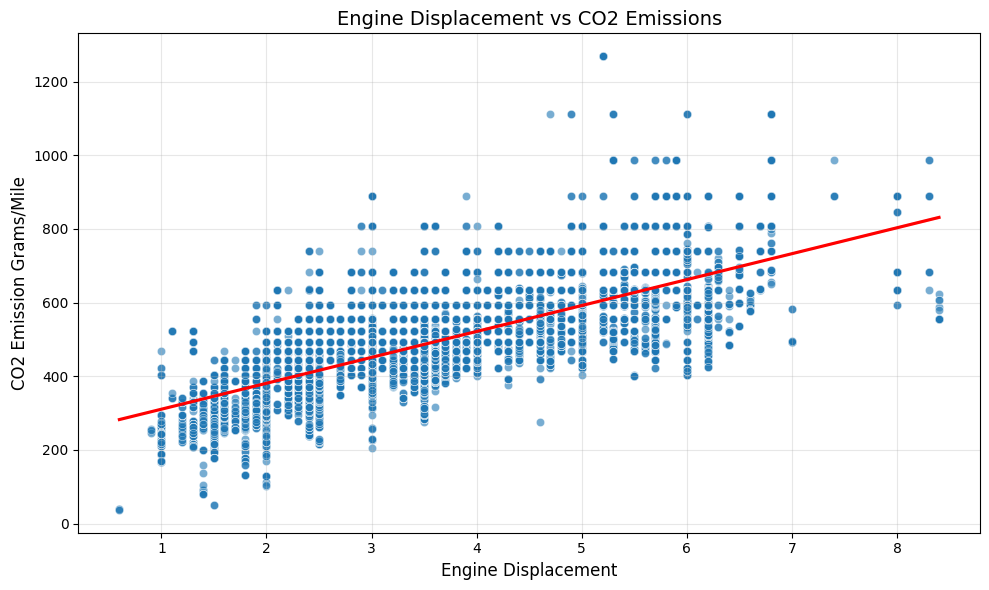

In [7]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Engine Displacement', y='CO2 Emission Grams/Mile', data=df, alpha=0.6)

# Add title and labels
plt.title('Engine Displacement vs CO2 Emissions', fontsize=14)
plt.xlabel('Engine Displacement (L)', fontsize=12)
plt.ylabel('CO2 Emissions (g/mile)', fontsize=12)

# Add a regression line
sns.regplot(x='Engine Displacement', y='CO2 Emission Grams/Mile', data=df, 
            scatter=False, color='red')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


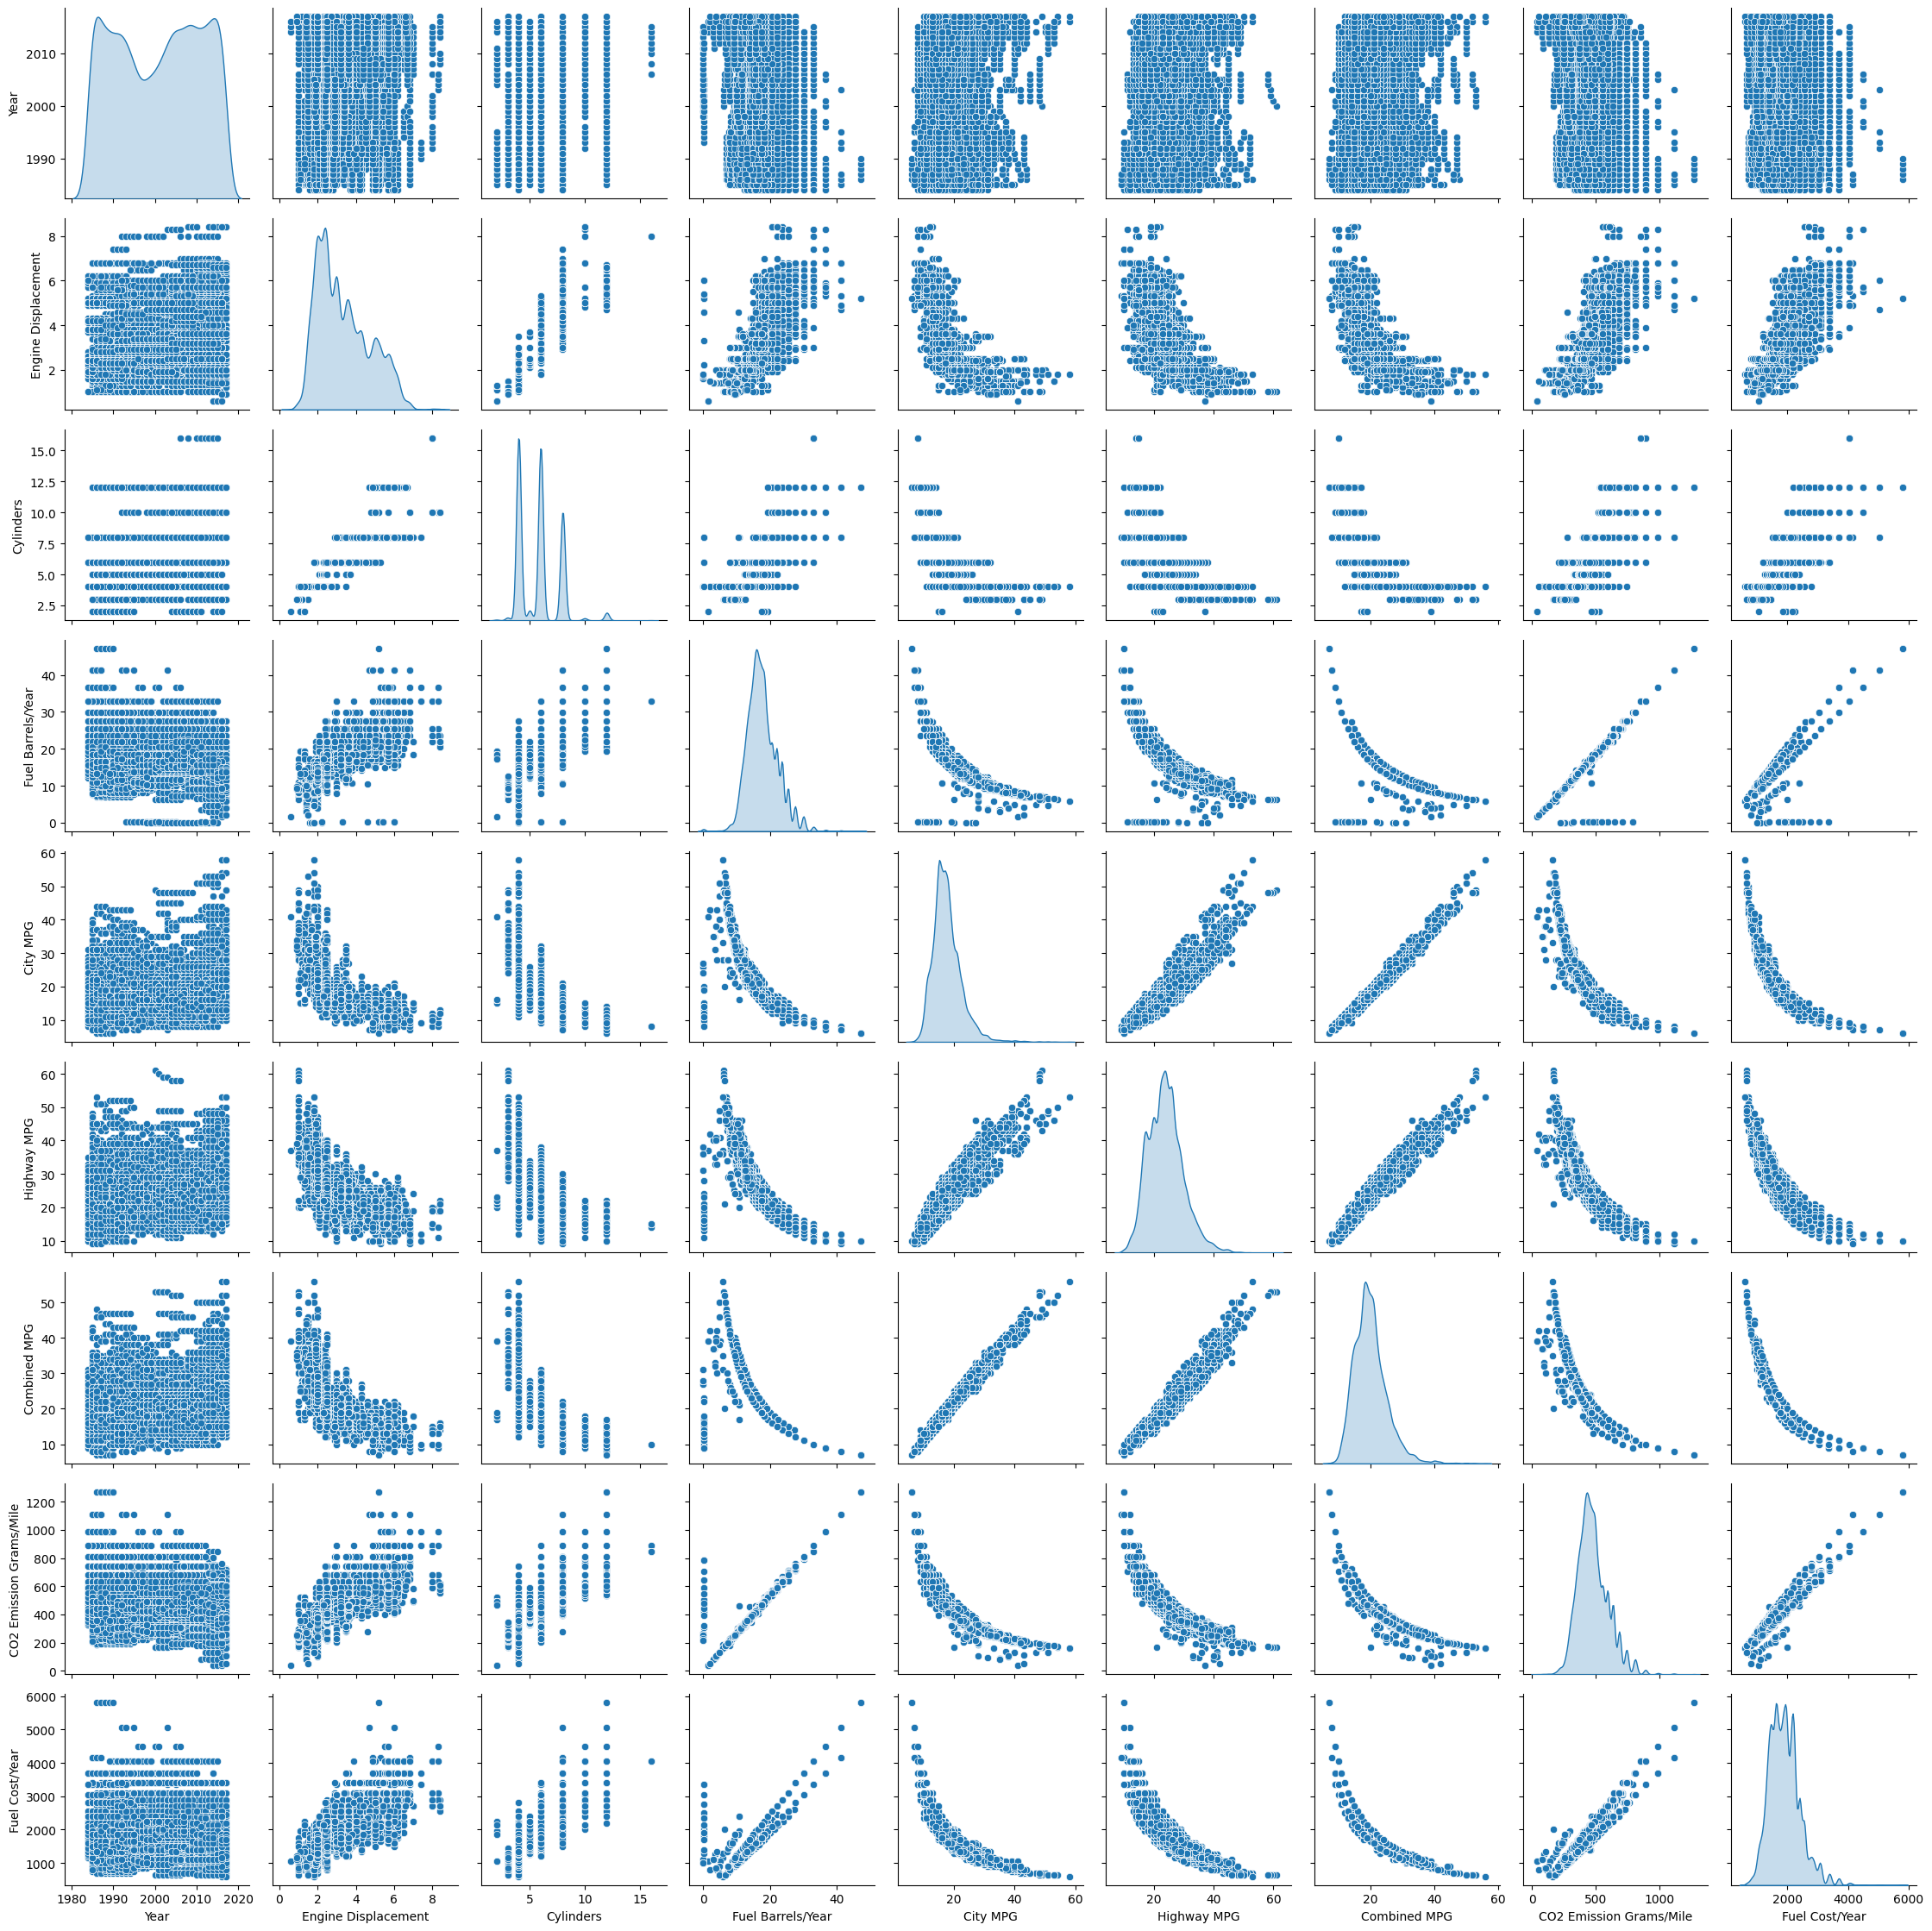

In [14]:
sns.pairplot(df, diag_kind='kde')

plt.tight_layout()
plt.show()

In [8]:
#rename columns
df.columns = df.columns.str.replace(' ', '_', regex=False).str.replace('/', '_', regex=False)


In [9]:
df.columns

Index(['Make', 'Model', 'Year', 'Engine_Displacement', 'Cylinders',
       'Transmission', 'Drivetrain', 'Vehicle_Class', 'Fuel_Type',
       'Fuel_Barrels_Year', 'City_MPG', 'Highway_MPG', 'Combined_MPG',
       'CO2_Emission_Grams_Mile', 'Fuel_Cost_Year'],
      dtype='object')

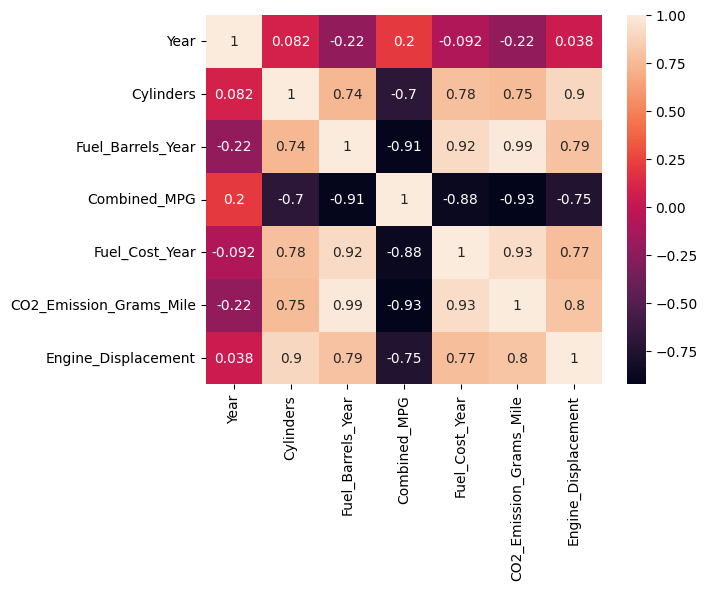

In [10]:
cars = df[['Year', 'Cylinders', 'Fuel_Barrels_Year', 'Combined_MPG', 'Fuel_Cost_Year', 'CO2_Emission_Grams_Mile','Engine_Displacement']]

sns.heatmap(cars.corr(), annot=True)
plt.show();

In [11]:
# Get the count of distinct values in the Drivetrain column
fuel_type_counts = df['Drivetrain'].value_counts()

# Display the results
print(fuel_type_counts)

Drivetrain
Front-Wheel Drive             13043
Rear-Wheel Drive              12722
4-Wheel or All-Wheel Drive     6498
All-Wheel Drive                2039
4-Wheel Drive                  1058
2-Wheel Drive                   423
Part-time 4-Wheel Drive         158
2-Wheel Drive, Front              1
Name: count, dtype: int64


In [12]:

df.loc[df['Drivetrain'].isin(['2-Wheel Drive- Front','Front-Wheel Drive']), 'Traction'] = 'Wheels_2_Front'
df.loc[df['Drivetrain'].isin(['4-Wheel Drive','4-Wheel or All-Wheel Drive','All-Wheel Drive',
                                         'Automatic 4-spd','Part-time 4-Wheel Drive']), 'Traction'] = 'Wheels_4'
df.loc[df['Drivetrain'].isin(['2-Wheel Drive','Rear-Wheel Drive']), 'Traction'] = 'Wheels_2_Back'

In [13]:
df.groupby('Traction')['CO2_Emission_Grams_Mile'].agg(['mean','count'])

,mean,count
Traction,,
Wheels_2_Back,530.615068,13145
Wheels_2_Front,385.083733,13043
Wheels_4,521.294919,9753


In [14]:
# Create new column 'Drivetrain_Category' based on the 'Traction' column
df['Drivetrain_Category'] = df['Traction'].apply(lambda x: 1 if x == 'Wheels_2_Front' else 0)

# Verify the categorization
traction_category_counts = df.groupby(['Traction', 'Drivetrain_Category']).size().reset_index(name='Count')
print(traction_category_counts)



         Traction  Drivetrain_Category  Count
0   Wheels_2_Back                    0  13145
1  Wheels_2_Front                    1  13043
2        Wheels_4                    0   9753


In [15]:
df.groupby('Drivetrain_Category')['CO2_Emission_Grams_Mile'].agg(['mean','count','std'])

,mean,count,std
Drivetrain_Category,,,
0,526.636072,22899,111.125851
1,385.083733,13043,67.840798


In [16]:
df.loc[df['Transmission'].str.contains('Auto'), 'Automatico'] = 1
df.loc[~df['Transmission'].str.contains('Auto'), 'Automatico'] = 0

In [17]:
df.groupby('Automatico')['CO2_Emission_Grams_Mile'].agg(['mean','count'])

,mean,count
Automatico,,
0.0,450.161732,11662
1.0,487.327035,24280


In [18]:
# Get the count of distinct values in the Fuel_Type column
fuel_type_counts = df['Fuel_Type'].value_counts()

# Display the results
print(fuel_type_counts)

Fuel_Type
Regular                        23585
Premium                         9913
Gasoline or E85                 1195
Diesel                           911
Premium or E85                   121
Midgrade                          74
CNG                               60
Premium and Electricity           20
Gasoline or natural gas           20
Premium Gas or Electricity        17
Regular Gas and Electricity       16
Gasoline or propane                8
Regular Gas or Electricity         2
Name: count, dtype: int64


In [19]:
# Define which fuel types belong to category 1
#gasoline = ['Regular', 'Premium', 'Gasoline or E85', 'Premium or E85', 'Midgrade']
gasoline = ['Regular']

# Create a new column with the categorization
df['Fuel_Category'] = df['Fuel_Type'].apply(lambda x: 1 if x in gasoline else 0)

# Verify the categorization
category_counts = df['Fuel_Category'].value_counts()
print("Category counts:")
print(category_counts)

Category counts:
Fuel_Category
1    23585
0    12357
Name: count, dtype: int64


In [20]:
df.groupby('Fuel_Category')['CO2_Emission_Grams_Mile'].agg(['mean','count'])

,mean,count
Fuel_Category,,
0,483.605459,12357
1,470.899889,23585


In [21]:
df.columns

Index(['Make', 'Model', 'Year', 'Engine_Displacement', 'Cylinders',
       'Transmission', 'Drivetrain', 'Vehicle_Class', 'Fuel_Type',
       'Fuel_Barrels_Year', 'City_MPG', 'Highway_MPG', 'Combined_MPG',
       'CO2_Emission_Grams_Mile', 'Fuel_Cost_Year', 'Traction',
       'Drivetrain_Category', 'Automatico', 'Fuel_Category'],
      dtype='object')

In [42]:
df.describe()

,Year,Engine_Displacement,Cylinders,Fuel_Barrels_Year,City_MPG,Highway_MPG,Combined_MPG,CO2_Emission_Grams_Mile,Fuel_Cost_Year,Automatico,Fuel_Category,Drivetrain_Category
count,35942.000000,35942.000000,35942.000000,35942.000000,35942.000000,35942.000000,35942.000000,35942.000000,35942.000000,35942.000000,35942.000000,35942.00000
mean,2000.716460,3.338084,5.764621,17.607261,17.647655,23.882839,19.931028,475.268113,1892.330699,0.675533,0.970675,0.36289
std,10.085477,1.359297,1.755234,4.466494,4.769072,5.890153,5.112055,119.039097,506.730622,0.468182,0.168718,0.48084
min,1984.000000,0.600000,2.000000,0.060000,6.000000,9.000000,7.000000,37.000000,600.000000,0.000000,0.000000,0.00000
25%,1991.000000,2.200000,4.000000,14.699423,15.000000,20.000000,16.000000,395.000000,1500.000000,0.000000,1.000000,0.00000
50%,2001.000000,3.000000,6.000000,17.347895,17.000000,24.000000,19.000000,467.736842,1850.000000,1.000000,1.000000,0.00000
75%,2010.000000,4.300000,6.000000,20.600625,20.000000,27.000000,23.000000,555.437500,2200.000000,1.000000,1.000000,1.00000
max,2017.000000,8.400000,16.000000,47.087143,58.000000,61.000000,56.000000,1269.571429,5800.000000,1.000000,1.000000,1.00000


In [22]:
df_dum = pd.get_dummies(df.Drivetrain_Category)
df_dum = df_dum.astype(int)
df_dum.head()

,0,1
0,1,0
1,1,0
2,1,0
3,1,0
4,1,0


In [46]:
df_concat_dum = pd.concat([df, df_dum], axis = 1)
df_concat_dum.head()

,Make,Model,Year,Engine_Displacement,Cylinders,Transmission,Drivetrain,Vehicle_Class,Fuel_Type,Fuel_Barrels_Year,...,Highway_MPG,Combined_MPG,CO2_Emission_Grams_Mile,Fuel_Cost_Year,Traction,Automatico,Fuel_Category,Drivetrain_Category,0,1
0,AM General,DJ Po Vehicle 2WD,1984,2.5,4,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,19.388824,...,17,17,522.764706,1950,Wheels_2_Back,1.0,1,0,1,0
1,AM General,FJ8c Post Office,1984,4.2,6,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,25.354615,...,13,13,683.615385,2550,Wheels_2_Back,1.0,1,0,1,0
2,AM General,Post Office DJ5 2WD,1985,2.5,4,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,20.600625,...,17,16,555.437500,2100,Wheels_2_Back,1.0,1,0,1,0
3,AM General,Post Office DJ8 2WD,1985,4.2,6,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,25.354615,...,13,13,683.615385,2550,Wheels_2_Back,1.0,1,0,1,0
4,ASC Incorporated,GNX,1987,3.8,6,Automatic 4-spd,Rear-Wheel Drive,Midsize Cars,Premium,20.600625,...,21,16,555.437500,2550,Wheels_2_Back,1.0,1,0,1,0


In [23]:
df.head(15)

,Make,Model,Year,Engine_Displacement,Cylinders,Transmission,Drivetrain,Vehicle_Class,Fuel_Type,Fuel_Barrels_Year,City_MPG,Highway_MPG,Combined_MPG,CO2_Emission_Grams_Mile,Fuel_Cost_Year,Traction,Drivetrain_Category,Automatico,Fuel_Category
0,AM General,DJ Po Vehicle 2WD,1984,2.5,4,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,19.388824,18,17,17,522.764706,1950,Wheels_2_Back,0,1.0,1
1,AM General,FJ8c Post Office,1984,4.2,6,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,25.354615,13,13,13,683.615385,2550,Wheels_2_Back,0,1.0,1
2,AM General,Post Office DJ5 2WD,1985,2.5,4,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,20.600625,16,17,16,555.437500,2100,Wheels_2_Back,0,1.0,1
3,AM General,Post Office DJ8 2WD,1985,4.2,6,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,25.354615,13,13,13,683.615385,2550,Wheels_2_Back,0,1.0,1
4,ASC Incorporated,GNX,1987,3.8,6,Automatic 4-spd,Rear-Wheel Drive,Midsize Cars,Premium,20.600625,14,21,16,555.437500,2550,Wheels_2_Back,0,1.0,0
5,Acura,2.2CL/3.0CL,1997,2.2,4,Automatic 4-spd,Front-Wheel Drive,Subcompact Cars,Regular,14.982273,20,26,22,403.954545,1500,Wheels_2_Front,1,1.0,1
6,Acura,2.2CL/3.0CL,1997,2.2,4,Manual 5-spd,Front-Wheel Drive,Subcompact Cars,Regular,13.733750,22,28,24,370.291667,1400,Wheels_2_Front,1,0.0,1
7,Acura,2.2CL/3.0CL,1997,3.0,6,Automatic 4-spd,Front-Wheel Drive,Subcompact Cars,Regular,16.480500,18,26,20,444.350000,1650,Wheels_2_Front,1,1.0,1
8,Acura,2.3CL/3.0CL,1998,2.3,4,Automatic 4-spd,Front-Wheel Drive,Subcompact Cars,Regular,14.982273,19,27,22,403.954545,1500,Wheels_2_Front,1,1.0,1
9,Acura,2.3CL/3.0CL,1998,2.3,4,Manual 5-spd,Front-Wheel Drive,Subcompact Cars,Regular,13.733750,21,29,24,370.291667,1400,Wheels_2_Front,1,0.0,1


In [24]:
# CO2_Emission_Grams_Mile is my target variable
X = df.drop('CO2_Emission_Grams_Mile', axis=1)  # This creates X with all columns except target variable
y = df['CO2_Emission_Grams_Mile']  # Your target variable

# Now split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [25]:
print(X_train.shape)
print(X_test.shape)

(28753, 18)
(7189, 18)


In [26]:
# get a list of continuos column, exclude binary columns
def get_continuous_columns(df):
    """
    Returns a list of continuous numeric columns (excluding binary 0/1 columns).
    
    Parameters:
    - df: DataFrame
    
    Returns:
    - List of column names
    """
    continuous_cols = []
    for col in df.select_dtypes(include=['int64', 'float64']).columns:
        if df[col].nunique() > 2:
            continuous_cols.append(col)
    return continuous_cols


In [56]:
continuous_columns_only= get_continuous_columns(X_train)
print(continuous_columns_only)

['Year', 'Engine_Displacement', 'Cylinders', 'Fuel_Barrels_Year', 'City_MPG', 'Highway_MPG', 'Combined_MPG', 'Fuel_Cost_Year']


In [27]:
continuous_columns_only= get_continuous_columns(X_test)
print(continuous_columns_only)

['Year', 'Engine_Displacement', 'Cylinders', 'Fuel_Barrels_Year', 'City_MPG', 'Highway_MPG', 'Combined_MPG', 'Fuel_Cost_Year']


In [28]:
scaler = StandardScaler()
scale_train = scaler.fit(X_train[['Year', 'Engine_Displacement', 'Cylinders', 'Fuel_Barrels_Year', 'City_MPG', 'Highway_MPG', 'Combined_MPG', 'Fuel_Cost_Year']])

X_train[['Year_St', 'Engine_Displacement_St', 'Cylinders_St', 'Fuel_Barrels_Year_St', 'City_MPG_St', 'Highway_MPG_St', 'Combined_MPG_St', 'Fuel_Cost_Year_St']] = scaler.transform(X_train[['Year', 'Engine_Displacement', 'Cylinders', 'Fuel_Barrels_Year', 'City_MPG', 'Highway_MPG', 'Combined_MPG', 'Fuel_Cost_Year']])

X_test[['Year_St', 'Engine_Displacement_St', 'Cylinders_St', 'Fuel_Barrels_Year_St', 'City_MPG_St', 'Highway_MPG_St', 'Combined_MPG_St', 'Fuel_Cost_Year_St']] = scaler.transform(X_test[['Year', 'Engine_Displacement', 'Cylinders', 'Fuel_Barrels_Year', 'City_MPG', 'Highway_MPG', 'Combined_MPG', 'Fuel_Cost_Year']])

X_train

,Make,Model,Year,Engine_Displacement,Cylinders,Transmission,Drivetrain,Vehicle_Class,Fuel_Type,Fuel_Barrels_Year,...,Automatico,Fuel_Category,Year_St,Engine_Displacement_St,Cylinders_St,Fuel_Barrels_Year_St,City_MPG_St,Highway_MPG_St,Combined_MPG_St,Fuel_Cost_Year_St
31621,Subaru,Sedan/3Door 4WD Turbo,1988,1.8,4,Automatic 4-spd,4-Wheel or All-Wheel Drive,Compact Cars,Regular,15.695714,...,1.0,1,-1.258512,-1.133571,-1.005460,-0.429355,0.284801,0.022032,0.211059,-0.578704
25763,Mitsubishi,Nativa 2WD,1999,3.0,6,Automatic 4-spd,Rear-Wheel Drive,Sport Utility Vehicle - 2WD,Regular,18.311667,...,1.0,1,-0.167739,-0.250316,0.132661,0.156881,-0.342925,-0.658400,-0.376128,-0.084634
28785,Pontiac,Sunbird,1985,1.8,4,Manual 5-spd,Front-Wheel Drive,Compact Cars,Regular,12.677308,...,0.0,1,-1.555995,-1.133571,-1.005460,-1.105781,1.121770,1.382896,1.189703,-1.171588
11135,Eagle,Talon,1996,2.0,4,Automatic 4-spd,Front-Wheel Drive,Subcompact Cars,Regular,15.695714,...,1.0,1,-0.465222,-0.986362,-1.005460,-0.429355,0.075559,0.532356,0.211059,-0.578704
32309,Toyota,4Runner 2WD,2000,3.4,6,Automatic 4-spd,Rear-Wheel Drive,Sport Utility Vehicle - 2WD,Regular,19.388824,...,1.0,1,-0.068578,0.044102,0.132661,0.398272,-0.342925,-0.828509,-0.571857,0.112994
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20757,Kia,Spectra,2002,1.8,4,Manual 5-spd,Front-Wheel Drive,Compact Cars,Regular,13.733750,...,0.0,1,0.129744,-1.133571,-1.005460,-0.869032,0.703286,0.872572,0.798245,-0.973960
32103,Suzuki,Sidekick Hardtop 4WD,1991,1.6,4,Manual 5-spd,4-Wheel or All-Wheel Drive,Special Purpose Vehicles,Regular,14.982273,...,0.0,1,-0.961028,-1.280780,-1.005460,-0.589237,0.703286,-0.148076,0.406788,-0.776332
30403,Saab,9-5 Wagon,2005,2.3,4,Automatic (S5),Front-Wheel Drive,Midsize Station Wagons,Premium,16.480500,...,1.0,0,0.427228,-0.765548,-1.005460,-0.253484,-0.133683,0.362248,0.015330,0.211808
21243,Lexus,GX 470,2008,4.7,8,Automatic 5-spd,4-Wheel or All-Wheel Drive,Sport Utility Vehicle - 4WD,Premium,21.974000,...,1.0,0,0.724711,1.000961,1.270783,0.977611,-0.761409,-0.998617,-0.963314,1.595203


In [29]:
# first model

# Use only the 'Fuel_Barrels_Year_St' feature
X_train_simple = X_train['Engine_Displacement_St']

# Add a constant for the intercept (important for statsmodels)
X_train_simple = sm.add_constant(X_train_simple)

# Fit the OLS regression model
model = sm.OLS(y_train, X_train_simple).fit()

# Display the detailed regression summary
print(model.summary())

                               OLS Regression Results                              
Dep. Variable:     CO2_Emission_Grams_Mile   R-squared:                       0.647
Model:                                 OLS   Adj. R-squared:                  0.647
Method:                      Least Squares   F-statistic:                 5.273e+04
Date:                     Tue, 20 May 2025   Prob (F-statistic):               0.00
Time:                             16:08:51   Log-Likelihood:            -1.6321e+05
No. Observations:                    28753   AIC:                         3.264e+05
Df Residuals:                        28751   BIC:                         3.264e+05
Df Model:                                1                                         
Covariance Type:                 nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------

In [31]:

import statsmodels.api as sm

# Select the features: 'Fuel_Barrels_Year_St' and the existing dummy 'Drivetrain_Category'
X_train_2_variables = X_train[['Engine_Displacement_St', 'Drivetrain_Category']]

# Add constant for intercept
X_train_2_variables = sm.add_constant(X_train_2_variables)

# Fit the model
model2 = sm.OLS(y_train, X_train_2_variables).fit()

# Display the summary
print(model2.summary())

                               OLS Regression Results                              
Dep. Variable:     CO2_Emission_Grams_Mile   R-squared:                       0.672
Model:                                 OLS   Adj. R-squared:                  0.672
Method:                      Least Squares   F-statistic:                 2.942e+04
Date:                     Tue, 20 May 2025   Prob (F-statistic):               0.00
Time:                             16:10:51   Log-Likelihood:            -1.6218e+05
No. Observations:                    28753   AIC:                         3.244e+05
Df Residuals:                        28750   BIC:                         3.244e+05
Df Model:                                2                                         
Covariance Type:                 nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------

In [ ]:
# calculate errors for model 1 (simople, 1 variable)
# Step 1: Add constant to X_test
#sm.OLS() does not automatically add an intercept term. You explicitly added one to X_train, so you must do the same to X_test before using .predict().
X_test_simple = sm.add_constant(X_test['Engine_Displacement_St'])

# Step 2: Predict using the statsmodels model
X_test["predict_SKL"] = model.predict(X_test_simple)

# Step 3: Evaluate the predictions
print("MAE: ", metrics.mean_absolute_error(y_test, X_test['predict_SKL']))
print("MSE: ", metrics.mean_squared_error(y_test, X_test['predict_SKL']))
print("RMSE: ", np.sqrt(metrics.mean_squared_error(y_test, X_test['predict_SKL'])))
print("R2: ", metrics.r2_score(y_test, X_test['predict_SKL']))

MAE:  53.21516096725591
MSE:  5158.455417852372
RMSE:  71.82238799881533
R2:  0.6391522635028475


In [34]:
X_train_2_variables = X_train[['Engine_Displacement_St', 'Drivetrain_Category']]

# Add constant for intercept
X_train_2_variables = sm.add_constant(X_train_2_variables)

# Fit the model
model2 = sm.OLS(y_train, X_train_2_variables).fit()

# calculate errors for model 2 (2 variables)
# Step 1: Add constant to X_test
#sm.OLS() does not automatically add an intercept term. You explicitly added one to X_train, so you must do the same to X_test before using .predict().
X_test_2_variables = sm.add_constant(X_test[['Engine_Displacement_St', 'Drivetrain_Category']])

# Step 2: Predict using the statsmodels model
X_test["predict_SKL"] = model2.predict(X_test_2_variables)

# Step 3: Evaluate the predictions
print("MAE: ", metrics.mean_absolute_error(y_test, X_test['predict_SKL']))
print("MSE: ", metrics.mean_squared_error(y_test, X_test['predict_SKL']))
print("RMSE: ", np.sqrt(metrics.mean_squared_error(y_test, X_test['predict_SKL'])))
print("R2: ", metrics.r2_score(y_test, X_test['predict_SKL']))

MAE:  50.600644449954146
MSE:  4773.510060220512
RMSE:  69.09059313843319
R2:  0.6660802195913726


Comparison of the two models:

1 variable
MAE:  53.21516096725591
MSE:  5158.455417852372
RMSE:  71.82238799881533
R2:  0.6391522635028475

2 variables
MAE:  50.600644449954146
MSE:  4773.510060220512
RMSE:  69.09059313843319
R2:  0.6660802195913726

MODEL 2 is better accross all evaluation metrics. Lower MAE, MSE, RMSE mean it's making smaller prediction errors. Higher R² means it's explaining more variance in the target variable. Adding the second variable improved performance, but only modestly. The improvements are small but consistent. The second variable has some predictive power, though it’s not dramatically more informative than the first. The two variables are most likely correlated limiting the added value of the second variable.